# spaCy vs SaT Segmenter Comparison
Side-by-side view of how each segmenter splits cleaned job-ad text.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import json, random
import pandas as pd
from IPython.display import display, HTML

from preprocessing.cleaner import clean_description
from segmenters import SpacySegmenter, SatSegmenter, HybridSegmenter

In [17]:
# ── Config ────────────────────────────────────────────────────────────────────
DATA_FILE  = "../data/raw/sample/sample.jsonl"
N_DOCS     = 10
SEED       = 42
SAT_MODEL  = "sat-3l-sm"

In [18]:
# ── Load & sample ─────────────────────────────────────────────────────────────
with open(DATA_FILE, encoding="utf-8") as f:
    records = [json.loads(line) for line in f if line.strip()]

random.seed(SEED)
random.shuffle(records)

docs = []
for rec in records:
    if len(docs) >= N_DOCS:
        break
    cleaned = clean_description(rec.get("text", ""))
    if cleaned.strip():
        docs.append({
            "id":      rec.get("usajobsControlNumber", "?"),
            "title":   rec.get("title", ""),
            "cleaned": cleaned,
        })

print(f"Loaded {len(docs)} docs")

Loaded 10 docs


In [ ]:
# ── Load segmenters ────────────────────────────────────────────────────────────
print("Loading spaCy …")
spacy_seg = SpacySegmenter()

print(f"Loading SaT ({SAT_MODEL}) …")
sat_seg = SatSegmenter(model=SAT_MODEL)

print("Building Hybrid (reuses above models) …")
hybrid_seg = HybridSegmenter(spacy_segmenter=spacy_seg, sat_segmenter=sat_seg)

print("Done.")

In [ ]:
# ── Segment ───────────────────────────────────────────────────────────────────
for doc in docs:
    doc["spacy"]  = spacy_seg.segment(doc["cleaned"])
    doc["sat"]    = sat_seg.segment(doc["cleaned"])
    doc["hybrid"] = hybrid_seg.segment(doc["cleaned"])

print("Segmentation complete.")

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for doc in docs:
    n_sp = len(doc["spacy"])
    n_hy = len(doc["hybrid"])
    n_st = len(doc["sat"])
    rows.append({
        "id":           doc["id"],
        "title":        doc["title"][:55],
        "chars":        len(doc["cleaned"]),
        "spaCy segs":   n_sp,
        "Hybrid segs":  n_hy,
        "SaT segs":     n_st,
        "hy-sp":        n_hy - n_sp,
        "st-hy":        n_st - n_hy,
    })

df = pd.DataFrame(rows)
display(df)

In [22]:
# ── Diff-style alignment view ─────────────────────────────────────────────────
import html as _html
import difflib

CSS = """
<style>
.cmp-wrap { font-family: system-ui, sans-serif; font-size: 13px; }
.cmp-doc  { border: 1px solid #ccd; border-radius: 6px; margin-bottom: 1.4rem;
            padding: .8rem 1rem; background: #fafbfc; }
.cmp-doc h3 { margin: 0 0 .4rem; font-size: .95rem; color: #0d2060; }
.cmp-meta  { font-size: .78rem; color: #666; margin-bottom: .4rem; }
details summary { cursor: pointer; font-size: .8rem; color: #336; user-select:none; }
pre.raw { background:#f0f2f5; border:1px solid #dde; border-radius:4px;
          padding:.5rem; white-space:pre-wrap; word-break:break-word;
          font-size:.75rem; max-height:140px; overflow-y:auto; margin:.3rem 0 .6rem; }
.legend { font-size:.76rem; margin-bottom:.5rem; display:flex; gap:1rem; }
.leg-sw { display:inline-block; width:12px; height:12px; border-radius:2px;
          margin-right:3px; vertical-align:middle; }
.tbl-wrap { max-height:420px; overflow-y:auto;
            border:1px solid #dde; border-radius:4px; }
table.cmp { border-collapse:collapse; width:100%; table-layout:fixed; }
table.cmp thead tr { position:sticky; top:0; z-index:1; }
table.cmp th { background:#2a4080; color:#fff; padding:.4rem .6rem;
               font-size:.82rem; width:50%; text-align:left; }

/* ── match block (collapsed summary row) ── */
tr.eq-blk td   { background:#f0f0f0; color:#666; font-size:.75rem;
                 padding:.2rem .6rem; border-bottom:2px solid #d0d0d0; }
tr.eq-blk .seg-m { font-size:.78rem; color:#444; padding:.15rem 0;
                   border-bottom:1px solid #e0e0e0; }

/* ── diff block (one row per disagreement zone) ── */
tr.diff-blk td { vertical-align:top; padding:.3rem .5rem;
                 border-bottom:2px solid #ccc; }
tr.diff-blk td:first-child { background:#eef4ff; border-right:1px solid #ccd; }
tr.diff-blk td:last-child  { background:#fff4f4; }

.seg-sp { font-size:.79rem; color:#1e3a8a; padding:.18rem .1rem;
          border-bottom:1px solid #c7d9f8; word-break:break-word; }
.seg-st { font-size:.79rem; color:#7f1d1d; padding:.18rem .1rem;
          border-bottom:1px solid #fcc; word-break:break-word; }
.seg-sp:last-child, .seg-st:last-child { border-bottom:none; }
.idx  { color:#aaa; font-size:.7rem; margin-right:.25rem; }
.empty { color:#bbb; font-style:italic; font-size:.78rem; }
</style>
"""

LEGEND = """
<div class="legend">
  <span><span class="leg-sw" style="background:#eef4ff;border:1px solid #aac"></span>spaCy only</span>
  <span><span class="leg-sw" style="background:#fff4f4;border:1px solid #faa"></span>SaT only</span>
  <span><span class="leg-sw" style="background:#f0f0f0;border:1px solid #ccc"></span>both agree (collapsed)</span>
</div>
"""

def _e(s): return _html.escape(str(s))

def seg_div(segs, i, css):
    return f'<div class="{css}"><span class="idx">{i+1}.</span>{_e(segs[i])}</div>'

def render_doc_diff(doc):
    sp = doc["spacy"]
    st = doc["sat"]
    opcodes = difflib.SequenceMatcher(None, sp, st, autojunk=False).get_opcodes()
    n_match = sum(i2 - i1 for tag, i1, i2, *_ in opcodes if tag == "equal")

    rows = []
    i = 0
    while i < len(opcodes):
        tag, i1, i2, j1, j2 = opcodes[i]

        if tag == "equal":
            n = i2 - i1
            inner = "".join(seg_div(sp, i1 + k, "seg-m") for k in range(n))
            label = f'{n} segment{"s" if n > 1 else ""} match'
            rows.append(
                f'<tr class="eq-blk"><td colspan="2">'
                f'<details><summary>{label}</summary>{inner}</details>'
                f'</td></tr>'
            )
            i += 1

        else:
            # Collect all consecutive non-equal ops into one diff block
            sp_idx, st_idx = [], []
            while i < len(opcodes) and opcodes[i][0] != "equal":
                tag2, i1, i2, j1, j2 = opcodes[i]
                if tag2 in ("delete", "replace"):
                    sp_idx.extend(range(i1, i2))
                if tag2 in ("insert", "replace"):
                    st_idx.extend(range(j1, j2))
                i += 1

            sp_html = "".join(seg_div(sp, k, "seg-sp") for k in sp_idx) \
                      or '<span class="empty">nothing</span>'
            st_html = "".join(seg_div(st, k, "seg-st") for k in st_idx) \
                      or '<span class="empty">nothing</span>'

            rows.append(
                f'<tr class="diff-blk">'
                f'<td>{sp_html}</td>'
                f'<td>{st_html}</td>'
                f'</tr>'
            )

    body = "".join(rows) or '<tr><td colspan="2">—</td></tr>'
    pct  = round(100 * n_match / max(len(sp), len(st)))

    return (
        f'<div class="cmp-doc">'
        f'<h3>{_e(doc["title"] or "(no title)")}</h3>'
        f'<div class="cmp-meta">'
        f'id: {_e(doc["id"])} &bull; {len(doc["cleaned"])} chars &bull; '
        f'spaCy {len(sp)} segs &bull; SaT {len(st)} segs &bull; '
        f'<b>{n_match} matching ({pct}%)</b>'
        f'</div>'
        f'<details><summary>Cleaned text</summary>'
        f'<pre class="raw">{_e(doc["cleaned"])}</pre></details>'
        f'<div class="tbl-wrap">'
        f'<table class="cmp"><thead><tr>'
        f'<th>spaCy ({len(sp)})</th><th>SaT ({len(st)})</th>'
        f'</tr></thead><tbody>{body}</tbody></table>'
        f'</div></div>'
    )

html_out = (CSS + LEGEND + '<div class="cmp-wrap">'
            + "".join(render_doc_diff(d) for d in docs)
            + '</div>')
display(HTML(html_out))

In [ ]:
# ── Three-way comparison: spaCy | Hybrid | SaT ────────────────────────────────
# Alignment strategy: SaT is used as the right-hand reference (finest-grained).
# sp↔st and hy↔st diffs are computed independently; the SaT spine drives the
# row layout.  Each disagreement zone is one <tr> with three <td> cells so all
# three methods always sit at the same vertical height.
import html as _html3
import difflib as _dl3

CSS3 = """
<style>
.cmp3-wrap { font-family: system-ui, sans-serif; font-size: 13px; }
.cmp3-doc  { border:1px solid #ccd; border-radius:6px; margin-bottom:1.4rem;
             padding:.8rem 1rem; background:#fafbfc; }
.cmp3-doc h3 { margin:0 0 .3rem; font-size:.95rem; color:#0d2060; }
.cmp3-meta  { font-size:.76rem; color:#666; margin-bottom:.4rem; }
.legend3 { font-size:.74rem; margin-bottom:.5rem; display:flex; gap:1.2rem; flex-wrap:wrap; }
.leg-sw  { display:inline-block; width:12px; height:12px; border-radius:2px;
           margin-right:3px; vertical-align:middle; }
.tbl3-wrap { max-height:450px; overflow-y:auto; border:1px solid #dde; border-radius:4px; }
table.cmp3 { border-collapse:collapse; width:100%; table-layout:fixed; }
table.cmp3 thead tr { position:sticky; top:0; z-index:1; }
table.cmp3 th { color:#fff; padding:.4rem .5rem; font-size:.8rem;
                width:33.3%; text-align:left; }
table.cmp3 th:nth-child(1) { background:#1e40af; }
table.cmp3 th:nth-child(2) { background:#92400e; }
table.cmp3 th:nth-child(3) { background:#991b1b; }

/* all-three-agree (collapsed) */
tr.eq3 td { background:#f0f0f0; color:#666; font-size:.74rem;
            padding:.18rem .6rem; border-bottom:2px solid #d0d0d0; }
.seg-m3 { font-size:.77rem; color:#444; padding:.12rem 0;
          border-bottom:1px solid #e0e0e0; }

/* diff zone row */
tr.dz td { vertical-align:top; padding:.28rem .45rem;
           border-bottom:2px solid #c8c8c8; }
tr.dz td:nth-child(1) { background:#eff6ff; border-right:1px solid #bcd; }
tr.dz td:nth-child(2) { background:#fffbeb; border-right:1px solid #e0c87a; }
tr.dz td:nth-child(3) { background:#fff1f2; }

.seg-sp3 { font-size:.78rem; color:#1e3a8a; padding:.15rem .1rem;
           border-bottom:1px solid #bcd; word-break:break-word; }
.seg-hy3 { font-size:.78rem; color:#78350f; padding:.15rem .1rem;
           border-bottom:1px solid #d4a74a; word-break:break-word; }
.seg-st3 { font-size:.78rem; color:#7f1d1d; padding:.15rem .1rem;
           border-bottom:1px solid #fca5a5; word-break:break-word; }
.seg-sp3:last-child,.seg-hy3:last-child,.seg-st3:last-child { border-bottom:none; }
.idx3 { color:#aaa; font-size:.68rem; margin-right:.22rem; }
.empty3 { color:#bbb; font-style:italic; font-size:.77rem; }
details summary { cursor:pointer; font-size:.78rem; color:#336; user-select:none; }
</style>
"""

LEGEND3 = """
<div class="legend3">
  <span><span class="leg-sw" style="background:#eff6ff;border:1px solid #bcd"></span>spaCy</span>
  <span><span class="leg-sw" style="background:#fffbeb;border:1px solid #d4a74a"></span>Hybrid</span>
  <span><span class="leg-sw" style="background:#fff1f2;border:1px solid #fca5a5"></span>SaT</span>
  <span><span class="leg-sw" style="background:#f0f0f0;border:1px solid #ccc"></span>all three agree (collapsed)</span>
</div>
"""

def _e3(s): return _html3.escape(str(s))

def _sdiv(text, idx, css):
    return f'<div class="{css}"><span class="idx3">{idx+1}.</span>{_e3(text)}</div>'

def _hy_segs_for_st_range(hy_st_ops, hy, j1, j2):
    """Return (match_type, [hy_segs]) for the st[j1:j2] range.

    match_type is 'equal' only when hy matches st exactly for this range.
    """
    if j1 >= j2:
        return "equal", []
    hy_indices = []
    seen = set()
    for tag, i1, i2, k1, k2 in hy_st_ops:
        if k1 >= j2 or k2 <= j1:
            continue
        if tag == "equal":
            for k in range(max(k1, j1), min(k2, j2)):
                idx = i1 + (k - k1)
                if idx not in seen:
                    hy_indices.append(idx)
                    seen.add(idx)
        elif i1 < i2:
            for idx in range(i1, i2):
                if idx not in seen:
                    hy_indices.append(idx)
                    seen.add(idx)
    hy_indices.sort()
    segs = [hy[i] for i in hy_indices]
    # Check if this is a perfect equal match
    st_segs = list(range(j1, j2))
    is_equal = (len(hy_indices) == len(st_segs)
                and all(hy[hi] == hy_st_ops[0][0] or True for hi in hy_indices)
                and segs == [hy[i] for i in hy_indices])
    # Simpler equal check: hy_indices were all from 'equal' ops
    all_equal = True
    for tag, i1, i2, k1, k2 in hy_st_ops:
        if k1 >= j2 or k2 <= j1:
            continue
        if tag != "equal":
            all_equal = False
            break
    return ("equal" if all_equal else "diff"), segs


def render_doc_3way(doc):
    sp = doc["spacy"]
    hy = doc["hybrid"]
    st = doc["sat"]

    sp_st_ops = _dl3.SequenceMatcher(None, sp, st, autojunk=False).get_opcodes()
    hy_st_ops = _dl3.SequenceMatcher(None, hy, st, autojunk=False).get_opcodes()

    n_sp_st = sum(i2-i1 for tag,i1,i2,*_ in sp_st_ops if tag=="equal")
    n_hy_st = sum(i2-i1 for tag,i1,i2,*_ in hy_st_ops if tag=="equal")

    rows = []
    i = 0
    while i < len(sp_st_ops):
        tag, sp_i1, sp_i2, st_j1, st_j2 = sp_st_ops[i]

        if tag == "equal":
            n = sp_i2 - sp_i1
            match_type, hy_segs = _hy_segs_for_st_range(hy_st_ops, hy, st_j1, st_j2)

            if match_type == "equal" and hy_segs == list(st[st_j1:st_j2]):
                # All three agree — collapsed row
                inner = "".join(
                    f'<div class="seg-m3"><span class="idx3">{st_j1+k+1}.</span>{_e3(st[st_j1+k])}</div>'
                    for k in range(n)
                )
                label = f'{n} segment{"s" if n>1 else ""} — all three agree'
                rows.append(
                    f'<tr class="eq3"><td colspan="3">'
                    f'<details><summary>{label}</summary>{inner}</details>'
                    f'</td></tr>'
                )
            else:
                # sp==st but hy differs → diff zone
                sp_html = "".join(_sdiv(sp[sp_i1+k], sp_i1+k, "seg-sp3") for k in range(n))
                hy_html = "".join(_sdiv(s, idx, "seg-hy3") for idx, s in
                                  enumerate(hy_segs)) or '<span class="empty3">nothing</span>'
                st_html = "".join(_sdiv(st[st_j1+k], st_j1+k, "seg-st3") for k in range(n))
                rows.append(f'<tr class="dz"><td>{sp_html}</td><td>{hy_html}</td><td>{st_html}</td></tr>')
            i += 1

        else:
            # Collect consecutive non-equal sp↔st ops
            sp_idx = []
            st_j_lo, st_j_hi = 10**9, 0
            while i < len(sp_st_ops) and sp_st_ops[i][0] != "equal":
                tag2, i1, i2, j1, j2 = sp_st_ops[i]
                if tag2 in ("delete", "replace"):
                    sp_idx.extend(range(i1, i2))
                if j1 < j2:
                    st_j_lo = min(st_j_lo, j1)
                    st_j_hi = max(st_j_hi, j2)
                i += 1

            if st_j_lo > st_j_hi:
                st_j_lo = st_j_hi = 0

            st_idx = list(range(st_j_lo, st_j_hi))
            _, hy_segs = _hy_segs_for_st_range(hy_st_ops, hy, st_j_lo, st_j_hi)

            sp_html = "".join(_sdiv(sp[k], k, "seg-sp3") for k in sp_idx) \
                      or '<span class="empty3">nothing</span>'
            hy_html = "".join(_sdiv(s, idx, "seg-hy3") for idx, s in enumerate(hy_segs)) \
                      or '<span class="empty3">nothing</span>'
            st_html = "".join(_sdiv(st[k], k, "seg-st3") for k in st_idx) \
                      or '<span class="empty3">nothing</span>'

            rows.append(f'<tr class="dz"><td>{sp_html}</td><td>{hy_html}</td><td>{st_html}</td></tr>')

    body = "".join(rows) or '<tr><td colspan="3">—</td></tr>'
    pct_sp = round(100 * n_sp_st / max(len(st), 1))
    pct_hy = round(100 * n_hy_st / max(len(st), 1))

    return (
        f'<div class="cmp3-doc">'
        f'<h3>{_e3(doc["title"] or "(no title)")}</h3>'
        f'<div class="cmp3-meta">'
        f'spaCy {len(sp)} segs ({pct_sp}% match SaT) &bull; '
        f'Hybrid {len(hy)} segs ({pct_hy}% match SaT) &bull; '
        f'SaT {len(st)} segs'
        f'</div>'
        f'<div class="tbl3-wrap">'
        f'<table class="cmp3"><thead><tr>'
        f'<th>spaCy ({len(sp)})</th>'
        f'<th>Hybrid ({len(hy)})</th>'
        f'<th>SaT ({len(st)})</th>'
        f'</tr></thead><tbody>{body}</tbody></table>'
        f'</div></div>'
    )

html3 = (CSS3 + LEGEND3 + '<div class="cmp3-wrap">'
         + "".join(render_doc_3way(d) for d in docs)
         + '</div>')
display(HTML(html3))

## Timing Comparison

In [11]:
import time

REPEATS = 5  # repeat each doc N times to get stable averages

spacy_times, sat_times = [], []

for doc in docs:
    txt = doc["cleaned"]

    t0 = time.perf_counter()
    for _ in range(REPEATS):
        spacy_seg.segment(txt)
    spacy_times.append((time.perf_counter() - t0) / REPEATS)

    t0 = time.perf_counter()
    for _ in range(REPEATS):
        sat_seg.segment(txt)
    sat_times.append((time.perf_counter() - t0) / REPEATS)

timing_df = pd.DataFrame({
    "title":      [d["title"][:45] for d in docs],
    "chars":      [len(d["cleaned"]) for d in docs],
    "spaCy (s)":  [round(t, 4) for t in spacy_times],
    "SaT (s)":    [round(t, 4) for t in sat_times],
    "SaT/spaCy":  [round(st / sp, 1) for sp, st in zip(spacy_times, sat_times)],
})
timing_df.loc["TOTAL"] = [
    "", "",
    round(sum(spacy_times), 4),
    round(sum(sat_times), 4),
    round(sum(sat_times) / sum(spacy_times), 1),
]
display(timing_df)

,title,chars,spaCy (s),SaT (s),SaT/spaCy
0,Practical Nurse- Outpatient,11915,0.2747,1.3300,4.8
1,Supervisory Health System Specialist (Busines,10422,0.1424,1.0190,7.2
2,Health System Specialist,13330,0.2318,1.4331,6.2
3,Secretary,8858,0.2038,0.9433,4.6
4,Statistician (Health),9451,0.2021,0.9891,4.9
5,JOINT OPERATIONS CENTER TECHNICIAN (D1245000),9090,0.2180,0.9094,4.2
6,Supervisory Program Analyst (Informatics),10343,0.1917,1.0989,5.7
7,Program Manager,5521,0.1208,0.4962,4.1
8,Supervisory Interdisciplinary,14097,0.2773,1.5902,5.7
9,School Information Assistant (OA),11606,0.2549,1.2436,4.9


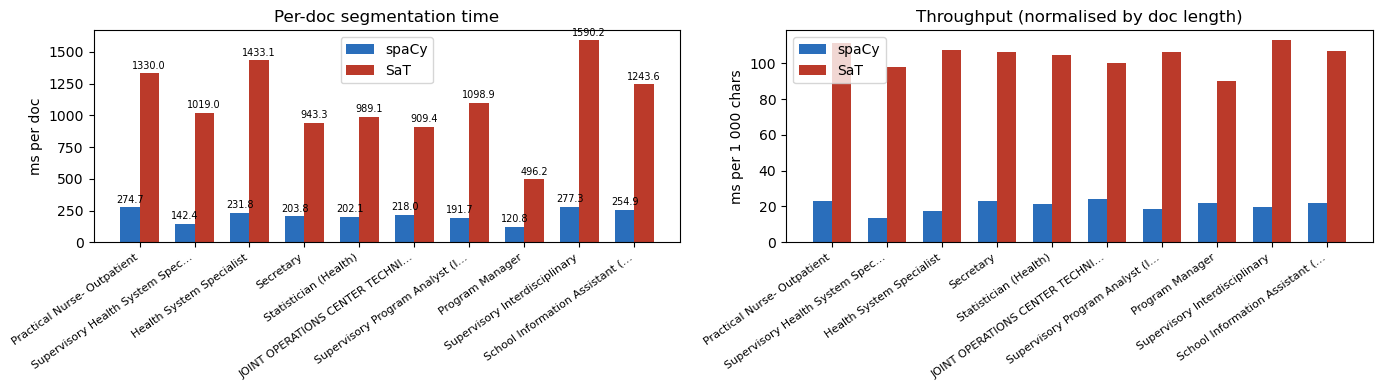


Aggregate:  spaCy 2117.6 ms  |  SaT 11052.9 ms  |  SaT is 5.2× slower


In [14]:
import matplotlib.pyplot as plt
import numpy as np

labels = [d["title"][:30] + "…" if len(d["title"]) > 30 else d["title"] for d in docs]
x = np.arange(len(docs))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Left: per-doc time ────────────────────────────────────────────────────────
ax = axes[0]
bars_sp = ax.bar(x - w/2, [t * 1000 for t in spacy_times], w, label="spaCy", color="#2a6ebb")
bars_st = ax.bar(x + w/2, [t * 1000 for t in sat_times],   w, label="SaT",   color="#bb3a2a")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("ms per doc")
ax.set_title("Per-doc segmentation time")
ax.legend()
ax.bar_label(bars_sp, fmt="%.1f", fontsize=7, padding=2)
ax.bar_label(bars_st, fmt="%.1f", fontsize=7, padding=2)

# ── Right: ms per 1000 chars ─────────────────────────────────────────────────
ax2 = axes[1]
chars = [len(d["cleaned"]) for d in docs]
sp_rate = [t * 1000 / (c / 1000) for t, c in zip(spacy_times, chars)]
st_rate = [t * 1000 / (c / 1000) for t, c in zip(sat_times,   chars)]
bars_sp2 = ax2.bar(x - w/2, sp_rate, w, label="spaCy", color="#2a6ebb")
bars_st2 = ax2.bar(x + w/2, st_rate, w, label="SaT",   color="#bb3a2a")
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax2.set_ylabel("ms per 1 000 chars")
ax2.set_title("Throughput (normalised by doc length)")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nAggregate:  spaCy {sum(spacy_times)*1000:.1f} ms  |  SaT {sum(sat_times)*1000:.1f} ms  "
      f"|  SaT is {sum(sat_times)/sum(spacy_times):.1f}× slower")